In [1]:
import os
os.chdir('/home/jovyan/signal-extraction') # set the current working directory to the base signal-extraction folder so vae and sim files and easily be called.

In [3]:
import xarray as xr

# Loading the reanalysis data

In [4]:
sdata1 = xr.open_dataset("./vae_input_data/sst_mon-mean.nc")
pdata1 = xr.open_dataset("./vae_input_data/tp_mon-sum.nc")

print(f"{sdata1}, /n {pdata1}")

<xarray.Dataset> Size: 34MB
Dimensions:          (valid_time: 1026, bnds: 2, latitude: 41, longitude: 201)
Coordinates:
  * valid_time       (valid_time) datetime64[ns] 8kB 1940-01-16 ... 2025-06-1...
  * latitude         (latitude) float64 328B 5.0 4.75 4.5 ... -4.5 -4.75 -5.0
  * longitude        (longitude) float64 2kB -170.0 -169.8 ... -120.2 -120.0
Dimensions without coordinates: bnds
Data variables:
    valid_time_bnds  (valid_time, bnds) datetime64[ns] 16kB ...
    sst              (valid_time, latitude, longitude) float32 34MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.1 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Thu Jul 24 17:53:53 2025: CDO monmean ./signal-e...
    frequency:               mon
    CDO:          

# Running the normVAE

In [5]:
from vae_code.HD_2.normVAE_HD2 import *

In [6]:
for Dim in range(1, 9):
    print(f"Starting run for Dim={Dim}...")
    mod = learn(sdata1, pdata1, "minmax", 'sst', 'tp', 0.8, 32, 100, Dim)
    train_summary(mod, f'./results/HD_norm2/D{Dim}/HD_norm2_D{Dim}_training_summary')
    ext = extractr(mod['model'], sdata1, 'sst', pdata1, 'tp', mod['sst_scaler'], mod['precip_scaler'], False, True, f"./results/HD_norm2/D{Dim}/HD_norm2_D{Dim}_extractr")
    print(f"Completed run for Dim={Dim} ✓\n")

Starting run for Dim=1...
Completed run for Dim=1 ✓

Starting run for Dim=2...
Completed run for Dim=2 ✓

Starting run for Dim=3...
Completed run for Dim=3 ✓

Starting run for Dim=4...
Completed run for Dim=4 ✓

Starting run for Dim=5...
Completed run for Dim=5 ✓

Starting run for Dim=6...
Completed run for Dim=6 ✓

Starting run for Dim=7...
Completed run for Dim=7 ✓

Starting run for Dim=8...
Completed run for Dim=8 ✓



In [11]:
import pandas as pd

path = './results/HD_norm2/D1/HD_norm2_D1_extractr_latent_full.csv'
df = pd.read_csv(path)
df['latent_dim'] = 0
df.to_csv(path, index=False)
print("Done ✓")

Done ✓


# Running the gammaVAE

In [7]:
from vae_code.HD_2.gammaVAE_HD2 import *

In [17]:
for Dim in range(1, 9):
    print(f"Starting run for Dim={Dim}...")
    mod = learn(sdata1, pdata1, "minmax", 'sst', 'tp', 1, 2, 0.8, 32, 100, Dim)
    train_summary(mod, f'./results/HD_gamma2/D{Dim}/HD_gamma2_D{Dim}_training_summary')
    ext = extractr(mod['model'], sdata1, 'sst', pdata1, 'tp', mod['sst_scaler'], mod['precip_scaler'], False, True, f"./results/HD_gamma2/D{Dim}/HD_gamma2_D{Dim}_extractr")
    print(f"Completed run for Dim={Dim} ✓\n")

Starting run for Dim=2...
Completed run for Dim=2 ✓



In [12]:
import pandas as pd

path = './results/HD_gamma2/D1/HD_gamma2_D1_extractr_latent_full.csv'
df = pd.read_csv(path)
df['latent_dim'] = 0
df.to_csv(path, index=False)
print("Done ✓")

Done ✓


# Running PCA on the latent spaces of the normally distributed model

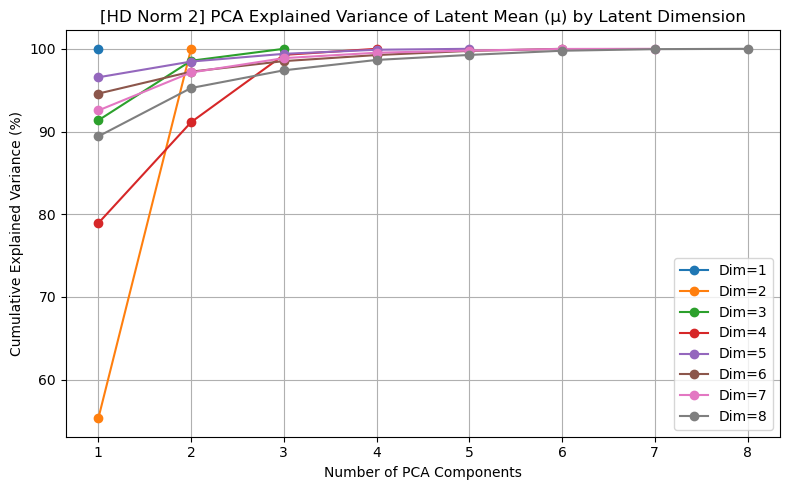

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dims = range(1, 9)
mu_by_dim = {}

for Dim in dims:
    path = f'./results/HD_norm2/D{Dim}/HD_norm2_D{Dim}_extractr_latent_full.csv'
    df = pd.read_csv(path)
    
    # Pivot to wide format: rows = timesteps, columns = latent dims
    mu_wide = df.pivot(index='time', columns='latent_dim', values='mu')
    mu_by_dim[Dim] = mu_wide.values

# --- Run PCA and plot explained variance ---
fig, ax = plt.subplots(figsize=(8, 5))

for Dim, mu in mu_by_dim.items():
    pca = PCA()
    pca.fit(mu)
    cumulative_var = np.cumsum(pca.explained_variance_ratio_) * 100
    ax.plot(range(1, Dim + 1), cumulative_var, marker='o', label=f'Dim={Dim}')

ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('[HD Norm 2] PCA Explained Variance of Latent Mean (μ) by Latent Dimension')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('./results/HD_norm2/PCA_explained_variance.png', dpi=150)
plt.show()

In [18]:
from sklearn.decomposition import PCA
import pandas as pd

for Dim in range(1, 9):
    path = f'./results/HD_norm2/D{Dim}/HD_norm2_D{Dim}_extractr_latent_full.csv'
    df = pd.read_csv(path)
    
    mu_wide = df.pivot(index='time', columns='latent_dim', values='latent')
    
    pca = PCA()
    pc_scores = pca.fit_transform(mu_wide.values)
    
    pc_df = pd.DataFrame(
        pc_scores,
        index=mu_wide.index,
        columns=[f'PC{i+1}' for i in range(Dim)]
    )
    pc_df.index.name = 'time'
    pc_df.to_csv(f'./results/HD_norm2/D{Dim}/HD_norm2_D{Dim}_PCs.csv')
    print(f"Saved PCs for Dim={Dim} ✓")

Saved PCs for Dim=1 ✓
Saved PCs for Dim=2 ✓
Saved PCs for Dim=3 ✓
Saved PCs for Dim=4 ✓
Saved PCs for Dim=5 ✓
Saved PCs for Dim=6 ✓
Saved PCs for Dim=7 ✓
Saved PCs for Dim=8 ✓


# Running PCA on the gamma distributed model

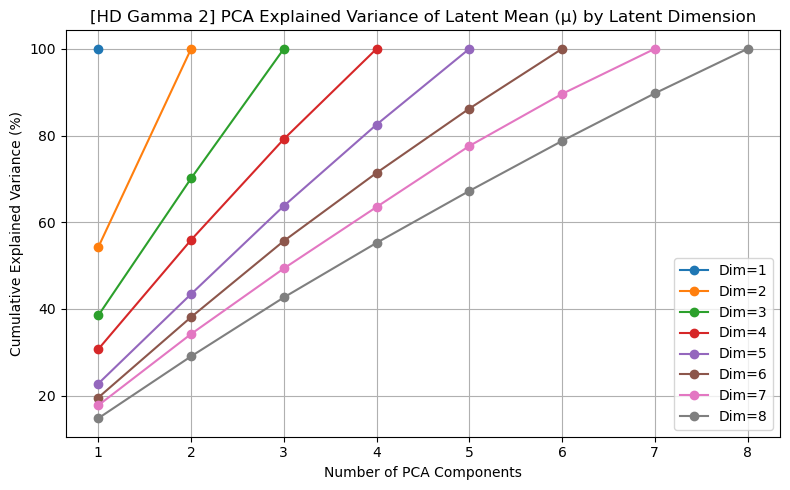

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dims = range(1, 9)
mu_by_dim = {}

for Dim in dims:
    path = f'./results/HD_gamma2/D{Dim}/HD_gamma2_D{Dim}_extractr_latent_full.csv'
    df = pd.read_csv(path)
    
    # Pivot to wide format: rows = timesteps, columns = latent dims
    mu_wide = df.pivot(index='time', columns='latent_dim', values='latent')
    mu_by_dim[Dim] = mu_wide.values

# --- Run PCA and plot explained variance ---
fig, ax = plt.subplots(figsize=(8, 5))

for Dim, mu in mu_by_dim.items():
    pca = PCA()
    pca.fit(mu)
    cumulative_var = np.cumsum(pca.explained_variance_ratio_) * 100
    ax.plot(range(1, Dim + 1), cumulative_var, marker='o', label=f'Dim={Dim}')

ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('[HD Gamma 2] PCA Explained Variance of Latent Mean (μ) by Latent Dimension')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('./results/HD_gamma2/gamma_PCA_explained_variance_D2to16.png', dpi=150)
plt.show()

In [20]:
from sklearn.decomposition import PCA
import pandas as pd

for Dim in range(1, 9):
    path = f'./results/HD_gamma2/D{Dim}/HD_gamma2_D{Dim}_extractr_latent_full.csv'
    df = pd.read_csv(path)
    
    mu_wide = df.pivot(index='time', columns='latent_dim', values='latent')
    
    pca = PCA()
    pc_scores = pca.fit_transform(mu_wide.values)
    
    pc_df = pd.DataFrame(
        pc_scores,
        index=mu_wide.index,
        columns=[f'PC{i+1}' for i in range(Dim)]
    )
    pc_df.index.name = 'time'
    pc_df.to_csv(f'./results/HD_gamma2/D{Dim}/HD_gamma2_D{Dim}_PCs.csv')
    print(f"Saved PCs for Dim={Dim} ✓")

Saved PCs for Dim=1 ✓
Saved PCs for Dim=2 ✓
Saved PCs for Dim=3 ✓
Saved PCs for Dim=4 ✓
Saved PCs for Dim=5 ✓
Saved PCs for Dim=6 ✓
Saved PCs for Dim=7 ✓
Saved PCs for Dim=8 ✓


# Loading the reference climate index timeseries

In [21]:
pna = pd.read_csv('~/signal-extraction/vae_input_data/ncep_pna_index.csv')
pdo = pd.read_csv('~/signal-extraction/vae_input_data/ncei_pdo_index.csv')
nino = pd.read_csv('~/signal-extraction/vae_input_data/psl_nino34_index_clean.csv')

# Calculating correlation coefficients for norm model. 

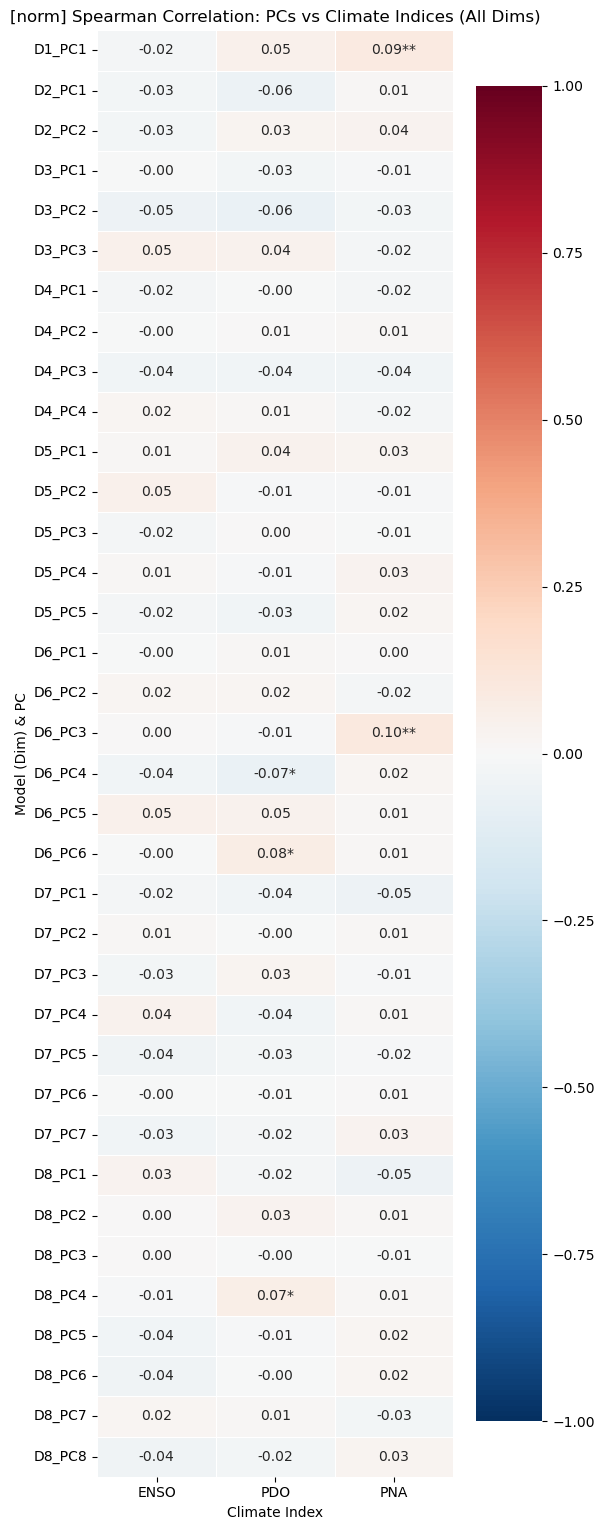

In [22]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dims_to_evaluate = range(1, 9)  # or specify a list like [3, 5, 7]

# --- Standardize climate indices ---
climate_indices = {
    'ENSO': nino.rename(columns={'DATE': 'time', 'INDEX': 'value'}),
    'PDO':  pdo.rename(columns={'Date': 'time'}),
    'PNA':  pna.rename(columns={'Date': 'time'}),
}

for name, df in climate_indices.items():
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    if not isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.to_period('M')

# --- Collect all correlations ---
all_corrs = {}
all_pvals = {}

for Dim in dims_to_evaluate:
    pc_df = pd.read_csv(f'./results/HD_norm2/D{Dim}/HD_norm2_D{Dim}_PCs.csv', index_col='time', parse_dates=True)
    pc_df.index = pc_df.index.to_period('M')

    combined = pc_df.copy()
    for name, idx_df in climate_indices.items():
        combined = combined.join(idx_df[['value']].rename(columns={'value': name}), how='inner')

    pc_cols = [c for c in combined.columns if c.startswith('PC')]
    index_cols = list(climate_indices.keys())

    for pc in pc_cols:
        for idx in index_cols:
            r, p = spearmanr(combined[pc], combined[idx])
            all_corrs[(f'D{Dim}_{pc}', idx)] = r
            all_pvals[(f'D{Dim}_{pc}', idx)] = p

# --- Build combined correlation and p-value matrices ---
corr_df = pd.Series(all_corrs).unstack()
pval_df = pd.Series(all_pvals).unstack()

# --- Build annotations with asterisks ---
annot = pd.DataFrame(index=corr_df.index, columns=corr_df.columns)
for row in corr_df.index:
    for col in corr_df.columns:
        r = corr_df.loc[row, col]
        p = pval_df.loc[row, col]
        stars = '**' if p < 0.01 else '*' if p < 0.05 else ''
        annot.loc[row, col] = f'{r:.2f}{stars}'

# --- Plot combined heatmap ---
fig, ax = plt.subplots(figsize=(6, len(corr_df) * 0.4 + 1))
sns.heatmap(
    corr_df.astype(float),
    annot=annot,
    fmt='',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
)

ax.set_title('[norm] Spearman Correlation: PCs vs Climate Indices (All Dims)')
ax.set_xlabel('Climate Index')
ax.set_ylabel('Model (Dim) & PC')
plt.tight_layout()
plt.savefig('./results/HD_norm2/HD_norm2_combined_spearman_corr_heatmap.png', dpi=150)
plt.show()

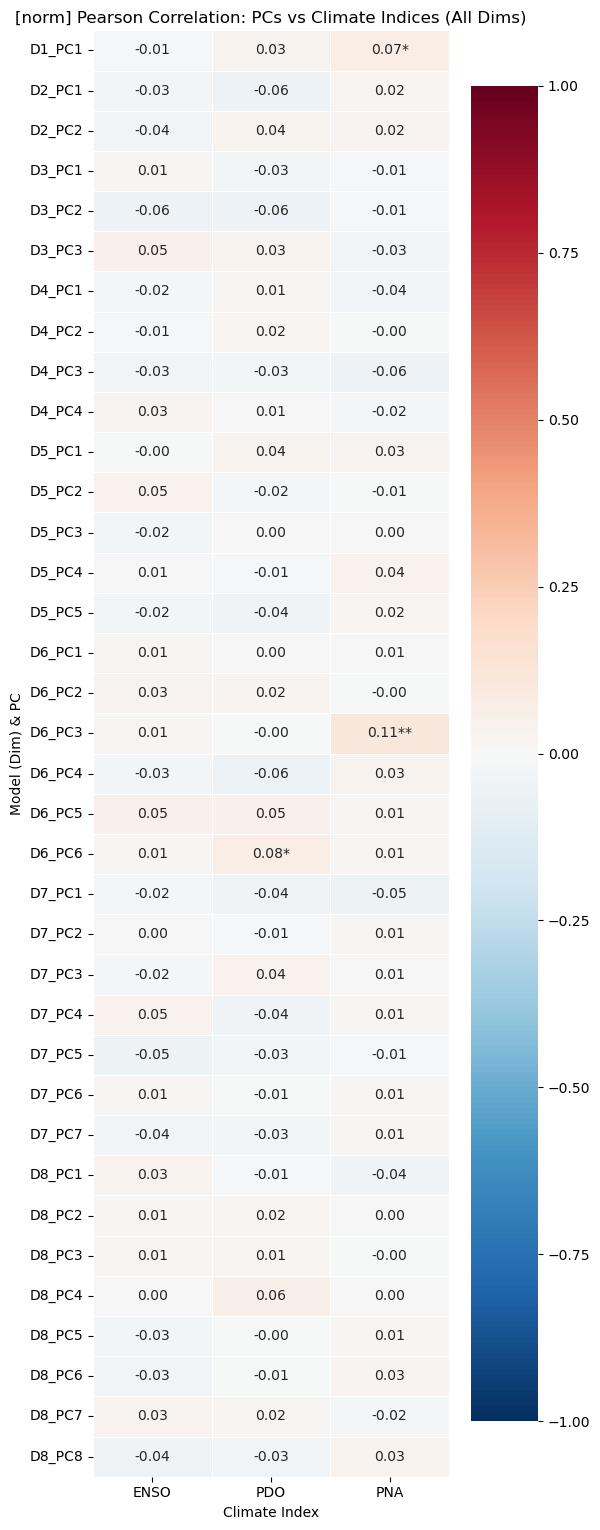

In [23]:
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dims_to_evaluate = range(1, 9)  # or specify a list like [3, 5, 7]

# --- Standardize climate indices ---
climate_indices = {
    'ENSO': nino.rename(columns={'DATE': 'time', 'INDEX': 'value'}),
    'PDO':  pdo.rename(columns={'Date': 'time'}),
    'PNA':  pna.rename(columns={'Date': 'time'}),
}

for name, df in climate_indices.items():
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    if not isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.to_period('M')

# --- Collect all correlations ---
all_corrs = {}
all_pvals = {}

for Dim in dims_to_evaluate:
    pc_df = pd.read_csv(f'./results/HD_norm2/D{Dim}/HD_norm2_D{Dim}_PCs.csv', index_col='time', parse_dates=True)
    pc_df.index = pc_df.index.to_period('M')

    combined = pc_df.copy()
    for name, idx_df in climate_indices.items():
        combined = combined.join(idx_df[['value']].rename(columns={'value': name}), how='inner')

    pc_cols = [c for c in combined.columns if c.startswith('PC')]
    index_cols = list(climate_indices.keys())

    for pc in pc_cols:
        for idx in index_cols:
            r, p = pearsonr(combined[pc], combined[idx])
            all_corrs[(f'D{Dim}_{pc}', idx)] = r
            all_pvals[(f'D{Dim}_{pc}', idx)] = p

# --- Build combined correlation and p-value matrices ---
corr_df = pd.Series(all_corrs).unstack()
pval_df = pd.Series(all_pvals).unstack()

# --- Build annotations with asterisks ---
annot = pd.DataFrame(index=corr_df.index, columns=corr_df.columns)
for row in corr_df.index:
    for col in corr_df.columns:
        r = corr_df.loc[row, col]
        p = pval_df.loc[row, col]
        stars = '**' if p < 0.01 else '*' if p < 0.05 else ''
        annot.loc[row, col] = f'{r:.2f}{stars}'

# --- Plot combined heatmap ---
fig, ax = plt.subplots(figsize=(6, len(corr_df) * 0.4 + 1))
sns.heatmap(
    corr_df.astype(float),
    annot=annot,
    fmt='',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
)

ax.set_title('[norm] Pearson Correlation: PCs vs Climate Indices (All Dims)')
ax.set_xlabel('Climate Index')
ax.set_ylabel('Model (Dim) & PC')
plt.tight_layout()
plt.savefig('./results/HD_norm2/HD_norm2_combined_pearson_corr_heatmap.png', dpi=150)
plt.show()

# Calculating correlation coefficients for gamma model

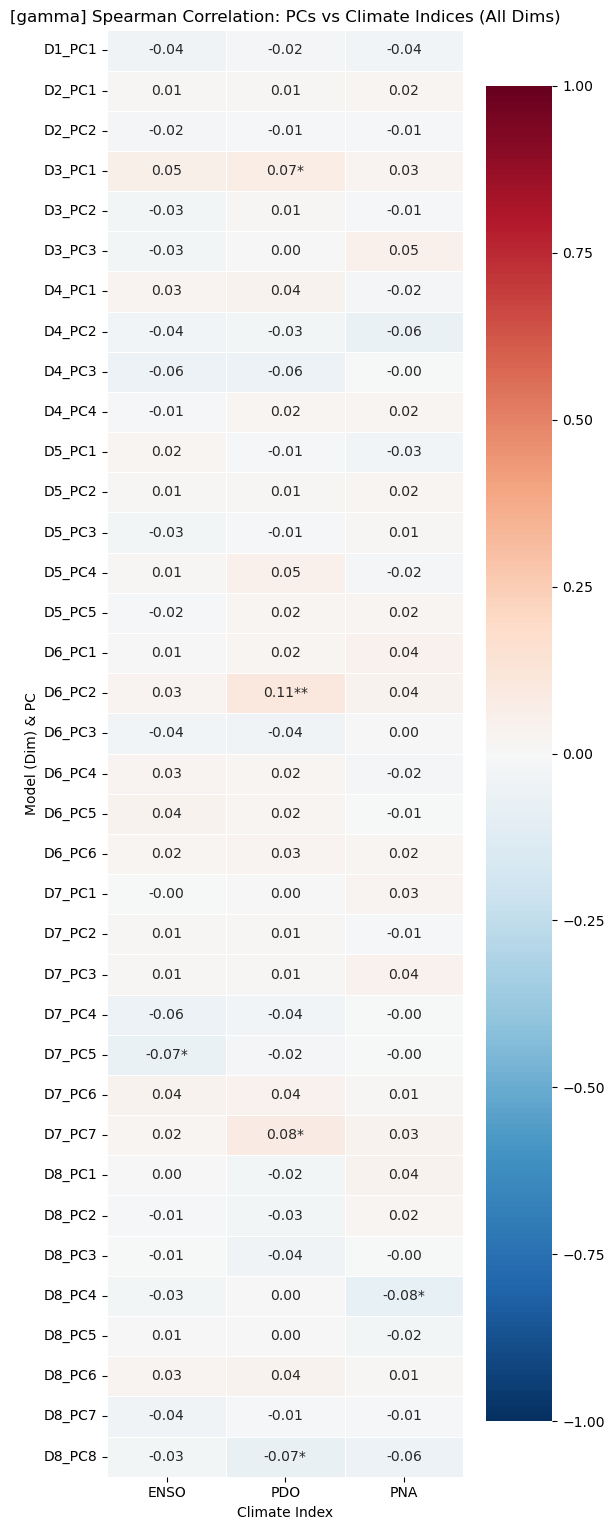

In [24]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dims_to_evaluate = range(1, 9)  # or specify a list like [3, 5, 7]

# --- Standardize climate indices ---
climate_indices = {
    'ENSO': nino.rename(columns={'DATE': 'time', 'INDEX': 'value'}),
    'PDO':  pdo.rename(columns={'Date': 'time'}),
    'PNA':  pna.rename(columns={'Date': 'time'}),
}

for name, df in climate_indices.items():
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    if not isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.to_period('M')

# --- Collect all correlations ---
all_corrs = {}
all_pvals = {}

for Dim in dims_to_evaluate:
    pc_df = pd.read_csv(f'./results/HD_gamma2/D{Dim}/HD_gamma2_D{Dim}_PCs.csv', index_col='time', parse_dates=True)
    pc_df.index = pc_df.index.to_period('M')

    combined = pc_df.copy()
    for name, idx_df in climate_indices.items():
        combined = combined.join(idx_df[['value']].rename(columns={'value': name}), how='inner')

    pc_cols = [c for c in combined.columns if c.startswith('PC')]
    index_cols = list(climate_indices.keys())

    for pc in pc_cols:
        for idx in index_cols:
            r, p = spearmanr(combined[pc], combined[idx])
            all_corrs[(f'D{Dim}_{pc}', idx)] = r
            all_pvals[(f'D{Dim}_{pc}', idx)] = p

# --- Build combined correlation and p-value matrices ---
corr_df = pd.Series(all_corrs).unstack()
pval_df = pd.Series(all_pvals).unstack()

# --- Build annotations with asterisks ---
annot = pd.DataFrame(index=corr_df.index, columns=corr_df.columns)
for row in corr_df.index:
    for col in corr_df.columns:
        r = corr_df.loc[row, col]
        p = pval_df.loc[row, col]
        stars = '**' if p < 0.01 else '*' if p < 0.05 else ''
        annot.loc[row, col] = f'{r:.2f}{stars}'

# --- Plot combined heatmap ---
fig, ax = plt.subplots(figsize=(6, len(corr_df) * 0.4 + 1))
sns.heatmap(
    corr_df.astype(float),
    annot=annot,
    fmt='',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
)

ax.set_title('[gamma] Spearman Correlation: PCs vs Climate Indices (All Dims)')
ax.set_xlabel('Climate Index')
ax.set_ylabel('Model (Dim) & PC')
plt.tight_layout()
plt.savefig('./results/HD_gamma2/HD_gamma2_combined_spearman_corr_heatmap.png', dpi=150)
plt.show()

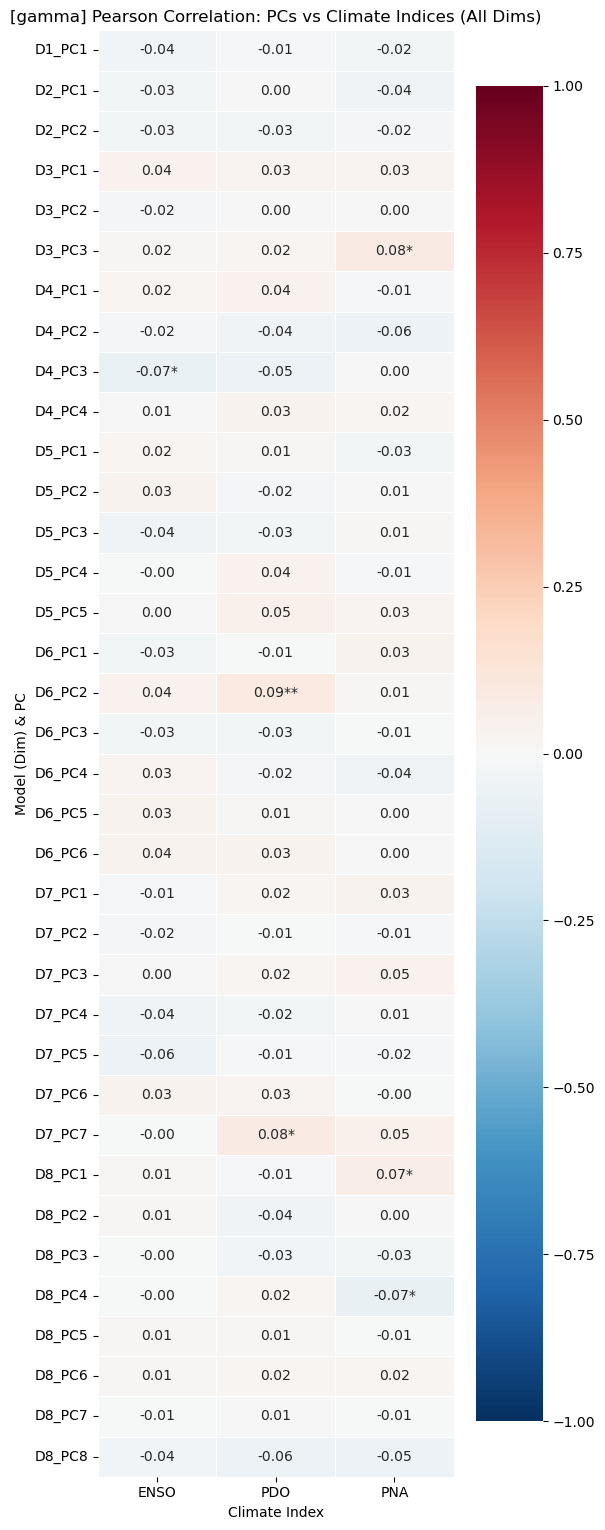

In [25]:
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dims_to_evaluate = range(1, 9)  # or specify a list like [3, 5, 7]

# --- Standardize climate indices ---
climate_indices = {
    'ENSO': nino.rename(columns={'DATE': 'time', 'INDEX': 'value'}),
    'PDO':  pdo.rename(columns={'Date': 'time'}),
    'PNA':  pna.rename(columns={'Date': 'time'}),
}

for name, df in climate_indices.items():
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    if not isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.to_period('M')

# --- Collect all correlations ---
all_corrs = {}
all_pvals = {}

for Dim in dims_to_evaluate:
    pc_df = pd.read_csv(f'./results/HD_gamma2/D{Dim}/HD_gamma2_D{Dim}_PCs.csv', index_col='time', parse_dates=True)
    pc_df.index = pc_df.index.to_period('M')

    combined = pc_df.copy()
    for name, idx_df in climate_indices.items():
        combined = combined.join(idx_df[['value']].rename(columns={'value': name}), how='inner')

    pc_cols = [c for c in combined.columns if c.startswith('PC')]
    index_cols = list(climate_indices.keys())

    for pc in pc_cols:
        for idx in index_cols:
            r, p = pearsonr(combined[pc], combined[idx])
            all_corrs[(f'D{Dim}_{pc}', idx)] = r
            all_pvals[(f'D{Dim}_{pc}', idx)] = p

# --- Build combined correlation and p-value matrices ---
corr_df = pd.Series(all_corrs).unstack()
pval_df = pd.Series(all_pvals).unstack()

# --- Build annotations with asterisks ---
annot = pd.DataFrame(index=corr_df.index, columns=corr_df.columns)
for row in corr_df.index:
    for col in corr_df.columns:
        r = corr_df.loc[row, col]
        p = pval_df.loc[row, col]
        stars = '**' if p < 0.01 else '*' if p < 0.05 else ''
        annot.loc[row, col] = f'{r:.2f}{stars}'

# --- Plot combined heatmap ---
fig, ax = plt.subplots(figsize=(6, len(corr_df) * 0.4 + 1))
sns.heatmap(
    corr_df.astype(float),
    annot=annot,
    fmt='',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
)

ax.set_title('[gamma] Pearson Correlation: PCs vs Climate Indices (All Dims)')
ax.set_xlabel('Climate Index')
ax.set_ylabel('Model (Dim) & PC')
plt.tight_layout()
plt.savefig('./results/HD_gamma2/HD_gamma2_combined_pearson_corr_heatmap.png', dpi=150)
plt.show()

# Trying to wavelet things

In [26]:
from evaluation.wavelet_class import *

Red Noise AR1 Coefficient: 0.007938712849763682
Red Noise AR1 Coefficient: -0.03731963243092781
Red Noise AR1 Coefficient: -0.008283815350396696
Red Noise AR1 Coefficient: -0.03527365285676291
Red Noise AR1 Coefficient: 0.04095157877387738
Red Noise AR1 Coefficient: 0.022160690174260877
Red Noise AR1 Coefficient: 0.0432903297128995
Red Noise AR1 Coefficient: -0.007315123206279552
Red Noise AR1 Coefficient: -0.014662918963763365
Red Noise AR1 Coefficient: 0.0017114393608990053
Red Noise AR1 Coefficient: 0.02809885437425765
Red Noise AR1 Coefficient: 0.052990824545705674
Red Noise AR1 Coefficient: 0.009409230582271784
Red Noise AR1 Coefficient: -0.03697313124929257
Red Noise AR1 Coefficient: -0.05958225871455337
Red Noise AR1 Coefficient: -0.055237432734103996
Red Noise AR1 Coefficient: 0.03743951745434244
Red Noise AR1 Coefficient: -0.015793006221578323
Red Noise AR1 Coefficient: -0.03827523857170494
Red Noise AR1 Coefficient: 0.04288673661635455
Red Noise AR1 Coefficient: 0.08711421309

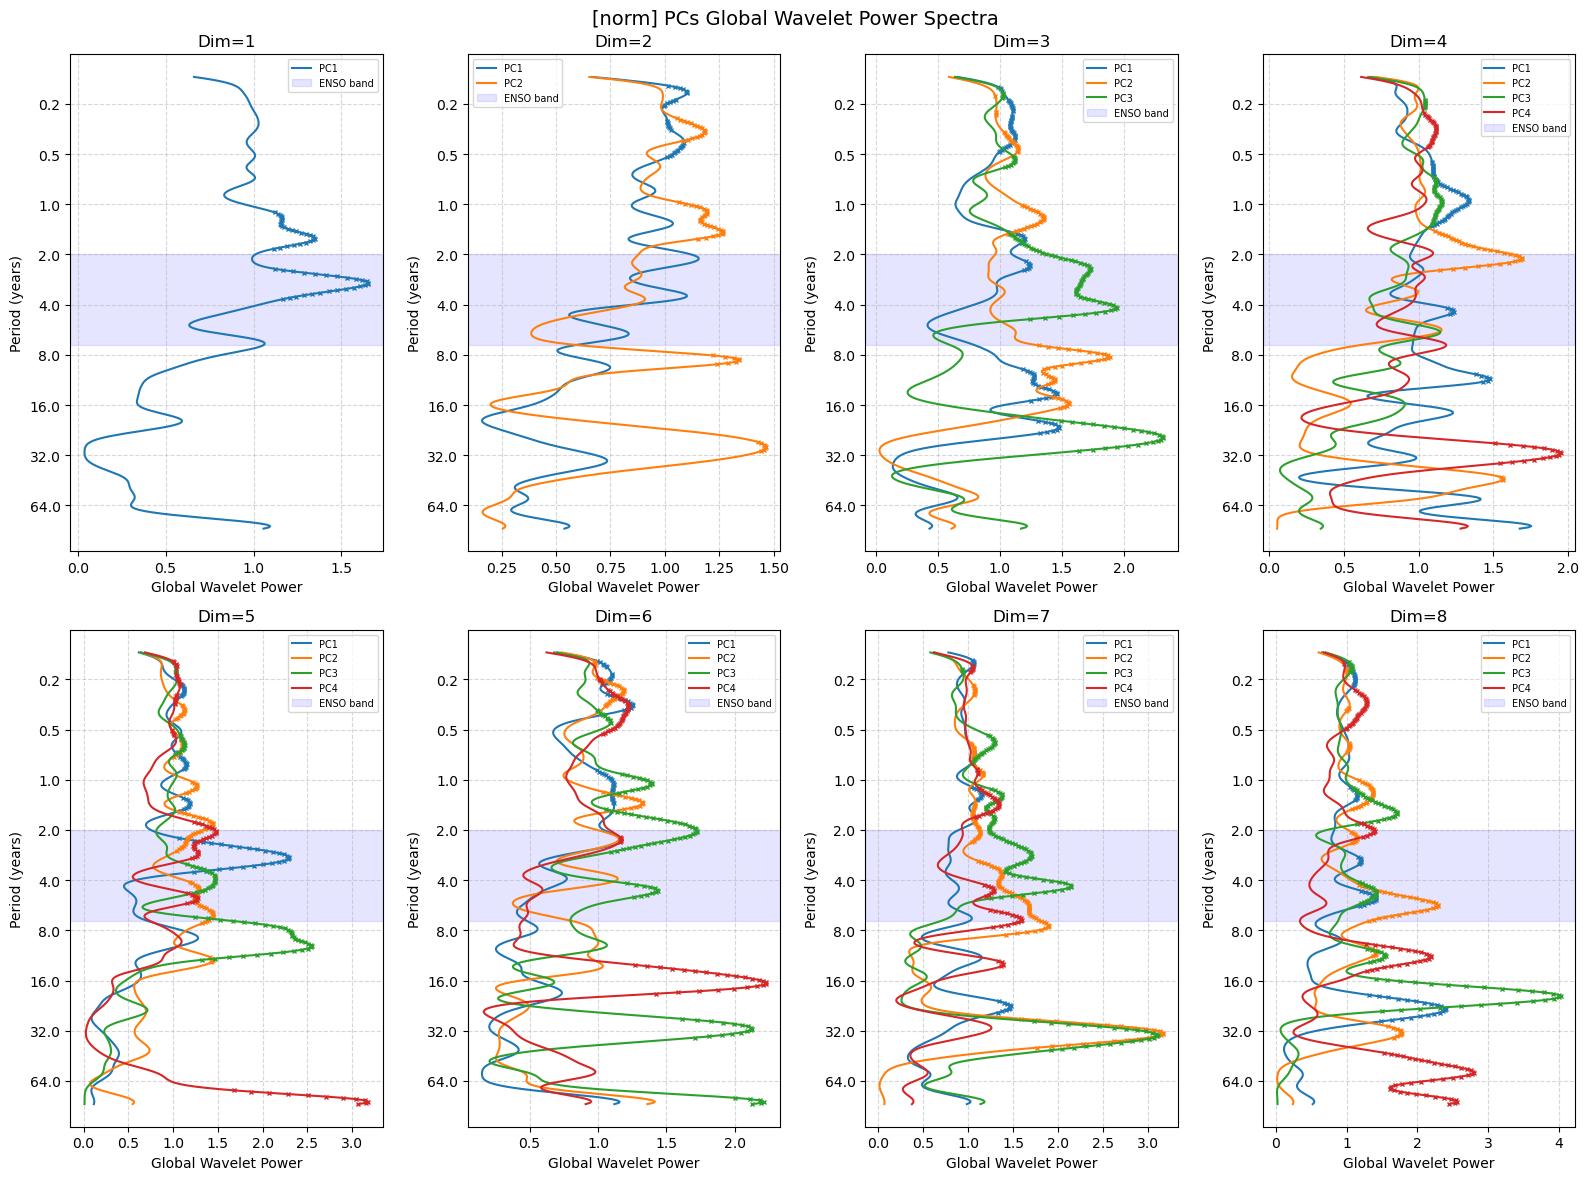

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

dims_to_evaluate = range(1, 9)
siglvl = 0.95
pc_limit = ['PC1', 'PC2', 'PC3', 'PC4']

config = WaveletConfig(dt=1/12, dj=0.025)
wa = WaveletAnalyzer(config)

n_dims = len(list(dims_to_evaluate))
n_cols = 4
n_rows = ceil(n_dims / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 6 * n_rows), sharey=False)
axes = np.array(axes).flatten()

for i, Dim in enumerate(dims_to_evaluate):
    ax = axes[i]
    pc_df = pd.read_csv(f'./results/HD_norm2/D{Dim}/HD_norm2_D{Dim}_PCs.csv', index_col='time', parse_dates=True)
    
    # restrict to PC1-4 and only those that exist in this Dim
    pc_cols = [pc for pc in pc_limit if pc in pc_df.columns]

    for pc in pc_cols:
        ts = pc_df[pc].dropna().values
        ts = (ts - ts.mean()) / ts.std()

        # --- CWT ---
        wlt = wa.cwt(ts)

        # --- Red noise significance ---
        wlt_ci = wa.confidence_interval(wlt, ts, conf=siglvl, noise_type='r')

        avg_power = wlt['avg_power']
        periods = wlt['period']
        sig = wlt_ci['sig']

        # --- Plot power curve ---
        line, = ax.plot(avg_power, periods, label=pc)

        # --- Annotate significant periods ---
        sig_mask = avg_power > sig
        ax.plot(
            avg_power[sig_mask],
            periods[sig_mask],
            'x',
            color=line.get_color(),
            markersize=3,
        )

    ax.axhspan(2, 7, alpha=0.1, color='blue', label='ENSO band')
    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))
    ax.invert_yaxis()
    ax.set_xlabel('Global Wavelet Power')
    ax.set_ylabel('Period (years)')
    ax.set_title(f'Dim={Dim}')
    ax.legend(fontsize=7)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

# --- Hide unused axes ---
for j in range(n_dims, n_rows * n_cols):
    axes[j].set_visible(False)

fig.suptitle('[norm] PCs Global Wavelet Power Spectra', fontsize=14)
plt.tight_layout()
plt.savefig('./results/HD_norm2/combined_global_wavelet.png', dpi=150, bbox_inches='tight')
plt.show()

# Gamma Global Wavelet Power Spectrum Plots

Red Noise AR1 Coefficient: -0.0010358341113178968
Red Noise AR1 Coefficient: 0.06118155259063085
Red Noise AR1 Coefficient: 0.05222900997551325
Red Noise AR1 Coefficient: 0.02346820906682341
Red Noise AR1 Coefficient: -0.011524110249370532
Red Noise AR1 Coefficient: -0.006209806197497147
Red Noise AR1 Coefficient: -0.009802240906094294
Red Noise AR1 Coefficient: -0.020017503174651813
Red Noise AR1 Coefficient: -0.0003060630419726073
Red Noise AR1 Coefficient: -0.04005092708142279
Red Noise AR1 Coefficient: -0.008228077570064881
Red Noise AR1 Coefficient: 0.015602474432452622
Red Noise AR1 Coefficient: -0.02437269348410481
Red Noise AR1 Coefficient: 0.03553934022700065
Red Noise AR1 Coefficient: -0.017673049038682973
Red Noise AR1 Coefficient: 0.0037644411589826737
Red Noise AR1 Coefficient: 0.030349740513070465
Red Noise AR1 Coefficient: -0.031269855039433594
Red Noise AR1 Coefficient: 0.008123172272880287
Red Noise AR1 Coefficient: 0.004506822711740409
Red Noise AR1 Coefficient: 0.056

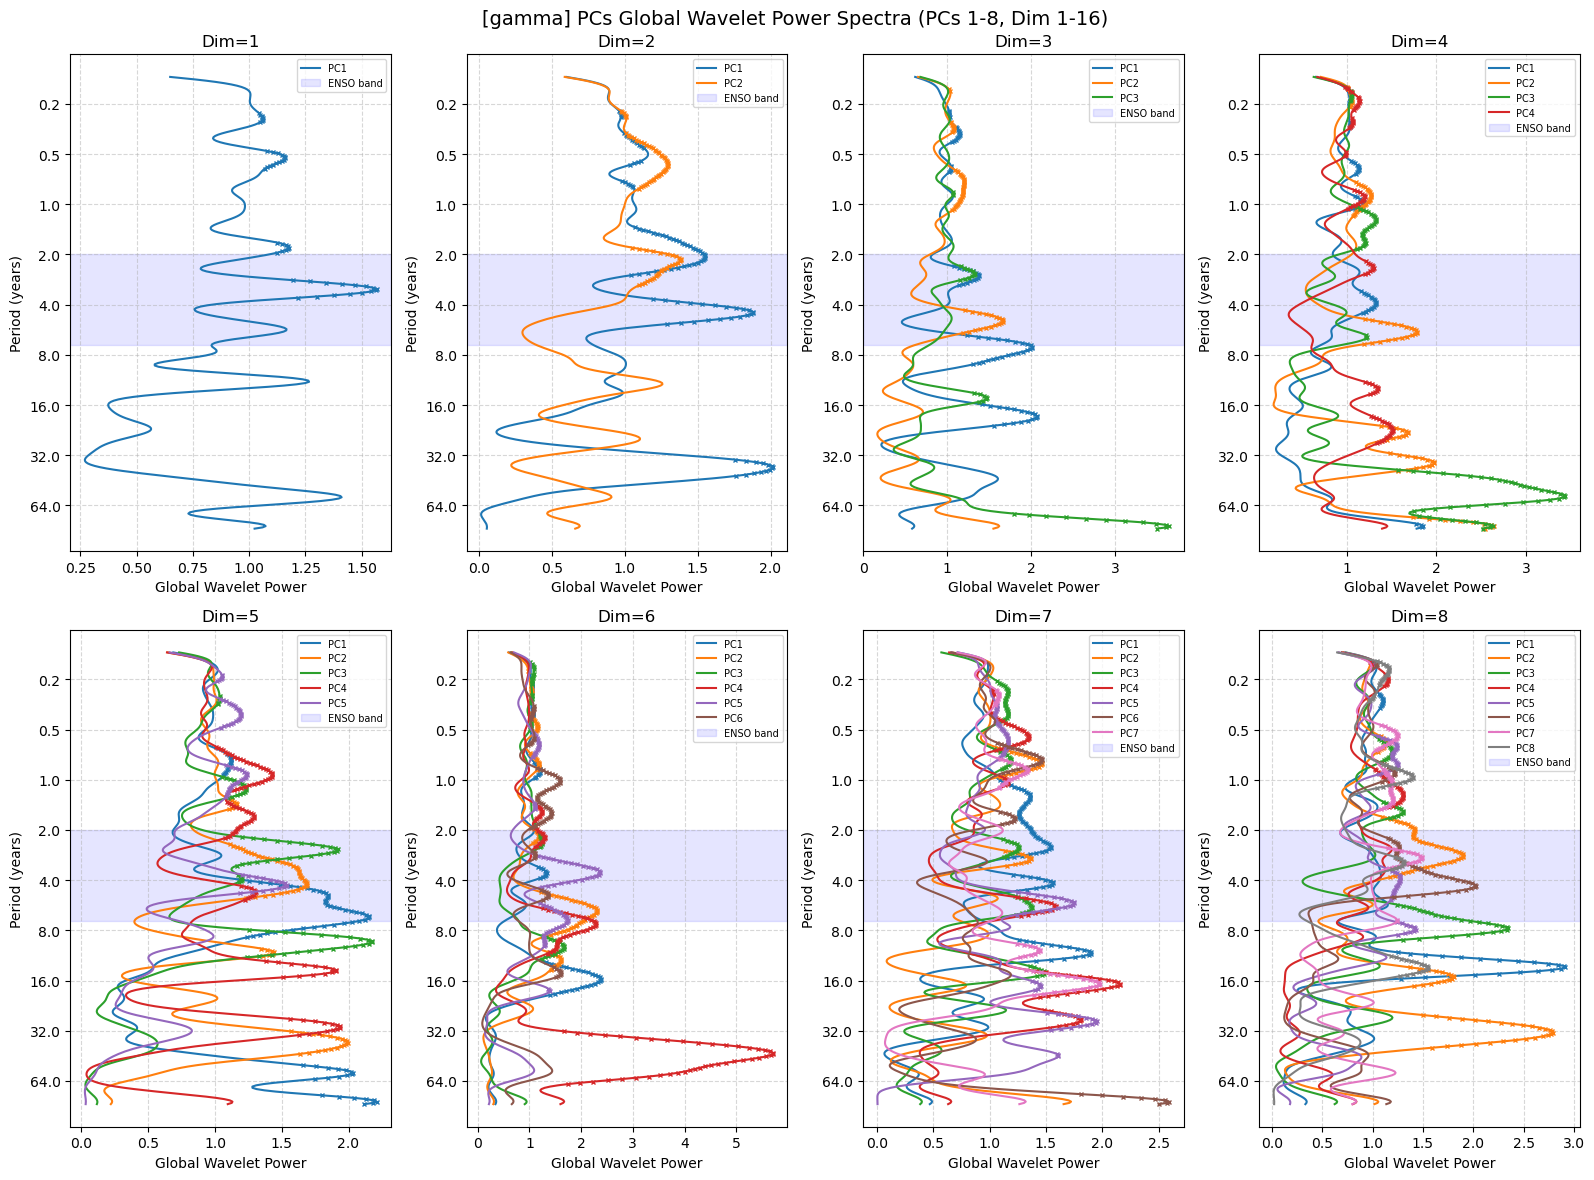

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

dims_to_evaluate = range(1, 9)
siglvl = 0.95
pc_limit = ['PC1', 'PC2', 'PC3', 'PC4']

config = WaveletConfig(dt=1/12, dj=0.025)
wa = WaveletAnalyzer(config)

n_dims = len(list(dims_to_evaluate))
n_cols = 4
n_rows = ceil(n_dims / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 6 * n_rows), sharey=False)
axes = np.array(axes).flatten()

for i, Dim in enumerate(dims_to_evaluate):
    ax = axes[i]
    pc_df = pd.read_csv(f'./results/HD_gamma2/D{Dim}/HD_gamma2_D{Dim}_PCs.csv', index_col='time', parse_dates=True)
    
    # restrict to PC1-4 and only those that exist in this Dim
    pc_cols = [pc for pc in pc_limit if pc in pc_df.columns]

    for pc in pc_cols:
        ts = pc_df[pc].dropna().values
        ts = (ts - ts.mean()) / ts.std()

        # --- CWT ---
        wlt = wa.cwt(ts)

        # --- Red noise significance ---
        wlt_ci = wa.confidence_interval(wlt, ts, conf=siglvl, noise_type='r')

        avg_power = wlt['avg_power']
        periods = wlt['period']
        sig = wlt_ci['sig']

        # --- Plot power curve ---
        line, = ax.plot(avg_power, periods, label=pc)

        # --- Annotate significant periods ---
        sig_mask = avg_power > sig
        ax.plot(
            avg_power[sig_mask],
            periods[sig_mask],
            'x',
            color=line.get_color(),
            markersize=3,
        )

    ax.axhspan(2, 7, alpha=0.1, color='blue', label='ENSO band')
    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))
    ax.invert_yaxis()
    ax.set_xlabel('Global Wavelet Power')
    ax.set_ylabel('Period (years)')
    ax.set_title(f'Dim={Dim}')
    ax.legend(fontsize=7)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

# --- Hide unused axes ---
for j in range(n_dims, n_rows * n_cols):
    axes[j].set_visible(False)

fig.suptitle('[gamma] PCs Global Wavelet Power Spectra (PCs 1-8, Dim 1-16)', fontsize=14)
plt.tight_layout()
plt.savefig('./results/HD_gamma2/combined_global_wavelet_alldims_8PCs.png', dpi=150, bbox_inches='tight')
plt.show()

Red Noise AR1 Coefficient: -0.0010358341113178968
Red Noise AR1 Coefficient: 0.06118155259063085
Red Noise AR1 Coefficient: 0.05222900997551325
Red Noise AR1 Coefficient: 0.02346820906682341
Red Noise AR1 Coefficient: -0.011524110249370532
Red Noise AR1 Coefficient: -0.006209806197497147
Red Noise AR1 Coefficient: -0.009802240906094294
Red Noise AR1 Coefficient: -0.020017503174651813
Red Noise AR1 Coefficient: -0.0003060630419726073
Red Noise AR1 Coefficient: -0.04005092708142279
Red Noise AR1 Coefficient: -0.008228077570064881
Red Noise AR1 Coefficient: 0.015602474432452622
Red Noise AR1 Coefficient: -0.02437269348410481
Red Noise AR1 Coefficient: 0.03553934022700065
Red Noise AR1 Coefficient: 0.0037644411589826737
Red Noise AR1 Coefficient: 0.030349740513070465
Red Noise AR1 Coefficient: -0.031269855039433594
Red Noise AR1 Coefficient: 0.008123172272880287
Red Noise AR1 Coefficient: 0.0026858096919537442
Red Noise AR1 Coefficient: -0.0027863868575497158
Red Noise AR1 Coefficient: 0.0

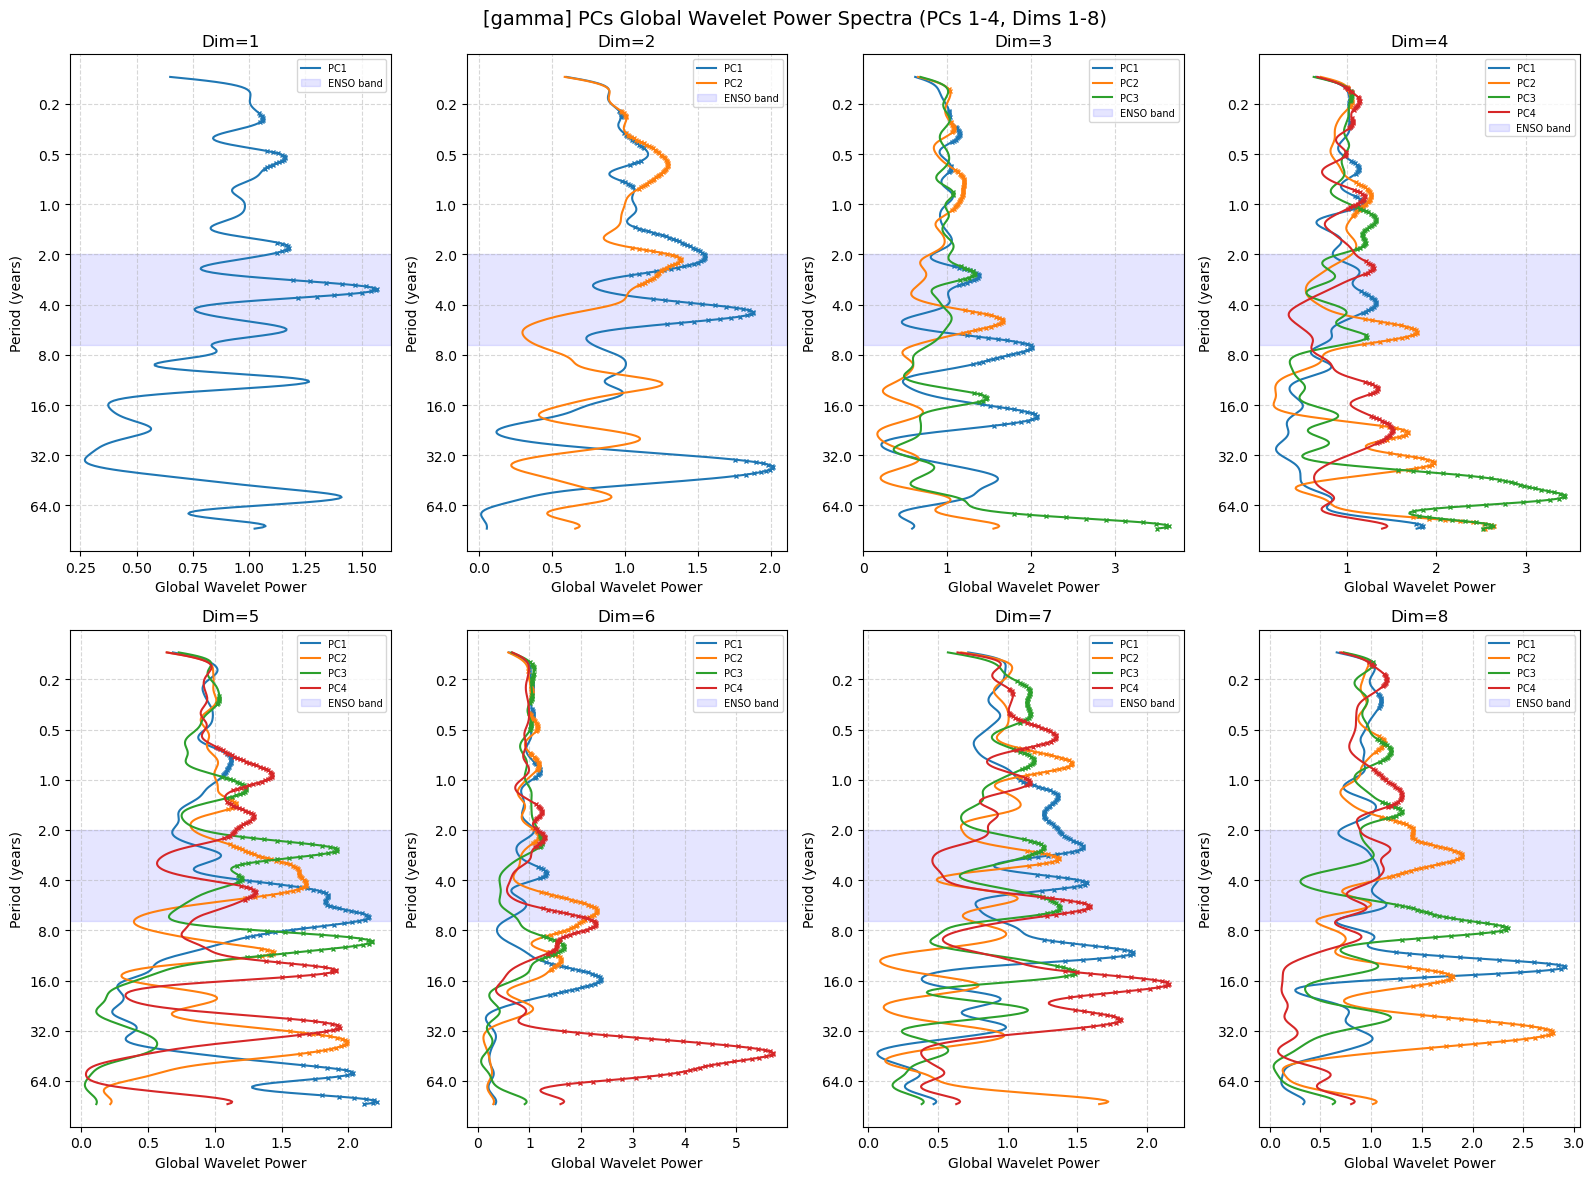

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

dims_to_evaluate = range(1, 9)
siglvl = 0.95
pc_limit = ['PC1', 'PC2', 'PC3', 'PC4']

config = WaveletConfig(dt=1/12, dj=0.025)
wa = WaveletAnalyzer(config)

n_dims = len(list(dims_to_evaluate))
n_cols = 4
n_rows = ceil(n_dims / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 6 * n_rows), sharey=False)
axes = np.array(axes).flatten()

for i, Dim in enumerate(dims_to_evaluate):
    ax = axes[i]
    pc_df = pd.read_csv(f'./results/HD_gamma2/D{Dim}/HD_gamma2_D{Dim}_PCs.csv', index_col='time', parse_dates=True)
    
    # restrict to PC1-4 and only those that exist in this Dim
    pc_cols = [pc for pc in pc_limit if pc in pc_df.columns]

    for pc in pc_cols:
        ts = pc_df[pc].dropna().values
        ts = (ts - ts.mean()) / ts.std()

        # --- CWT ---
        wlt = wa.cwt(ts)

        # --- Red noise significance ---
        wlt_ci = wa.confidence_interval(wlt, ts, conf=siglvl, noise_type='r')

        avg_power = wlt['avg_power']
        periods = wlt['period']
        sig = wlt_ci['sig']

        # --- Plot power curve ---
        line, = ax.plot(avg_power, periods, label=pc)

        # --- Annotate significant periods ---
        sig_mask = avg_power > sig
        ax.plot(
            avg_power[sig_mask],
            periods[sig_mask],
            'x',
            color=line.get_color(),
            markersize=3,
        )

    ax.axhspan(2, 7, alpha=0.1, color='blue', label='ENSO band')
    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))
    ax.invert_yaxis()
    ax.set_xlabel('Global Wavelet Power')
    ax.set_ylabel('Period (years)')
    ax.set_title(f'Dim={Dim}')
    ax.legend(fontsize=7)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

# --- Hide unused axes ---
for j in range(n_dims, n_rows * n_cols):
    axes[j].set_visible(False)

fig.suptitle('[gamma] PCs Global Wavelet Power Spectra (PCs 1-4, Dims 1-8)', fontsize=14)
plt.tight_layout()
plt.savefig('./results/HD_gamma2/gamma_combined_global_wavelet_clean.png', dpi=150, bbox_inches='tight')
plt.show()

Red Noise AR1 Coefficient: 0.5041827927963768
Red Noise AR1 Coefficient: 0.5021977724463941
Red Noise AR1 Coefficient: 0.30555634813469035
Red Noise AR1 Coefficient: 0.33858327576694114
Red Noise AR1 Coefficient: 0.4717758167108663
Red Noise AR1 Coefficient: 0.25062815769383096
Red Noise AR1 Coefficient: 0.5111388110832195
Red Noise AR1 Coefficient: 0.3451264745052459
Red Noise AR1 Coefficient: 0.1467247129035311
Red Noise AR1 Coefficient: 0.17068741699978385
Red Noise AR1 Coefficient: 0.404079654701855
Red Noise AR1 Coefficient: 0.3737926457777656
Red Noise AR1 Coefficient: 0.26852080322199984
Red Noise AR1 Coefficient: 0.15445887048360984
Red Noise AR1 Coefficient: 0.3183327989074004
Red Noise AR1 Coefficient: 0.5122949125370216
Red Noise AR1 Coefficient: 0.2547018109969527
Red Noise AR1 Coefficient: 0.1290550724616965
Red Noise AR1 Coefficient: 0.5339736403177057
Red Noise AR1 Coefficient: 0.3298236582997092
Red Noise AR1 Coefficient: 0.18745019576268546
Red Noise AR1 Coefficient: 0

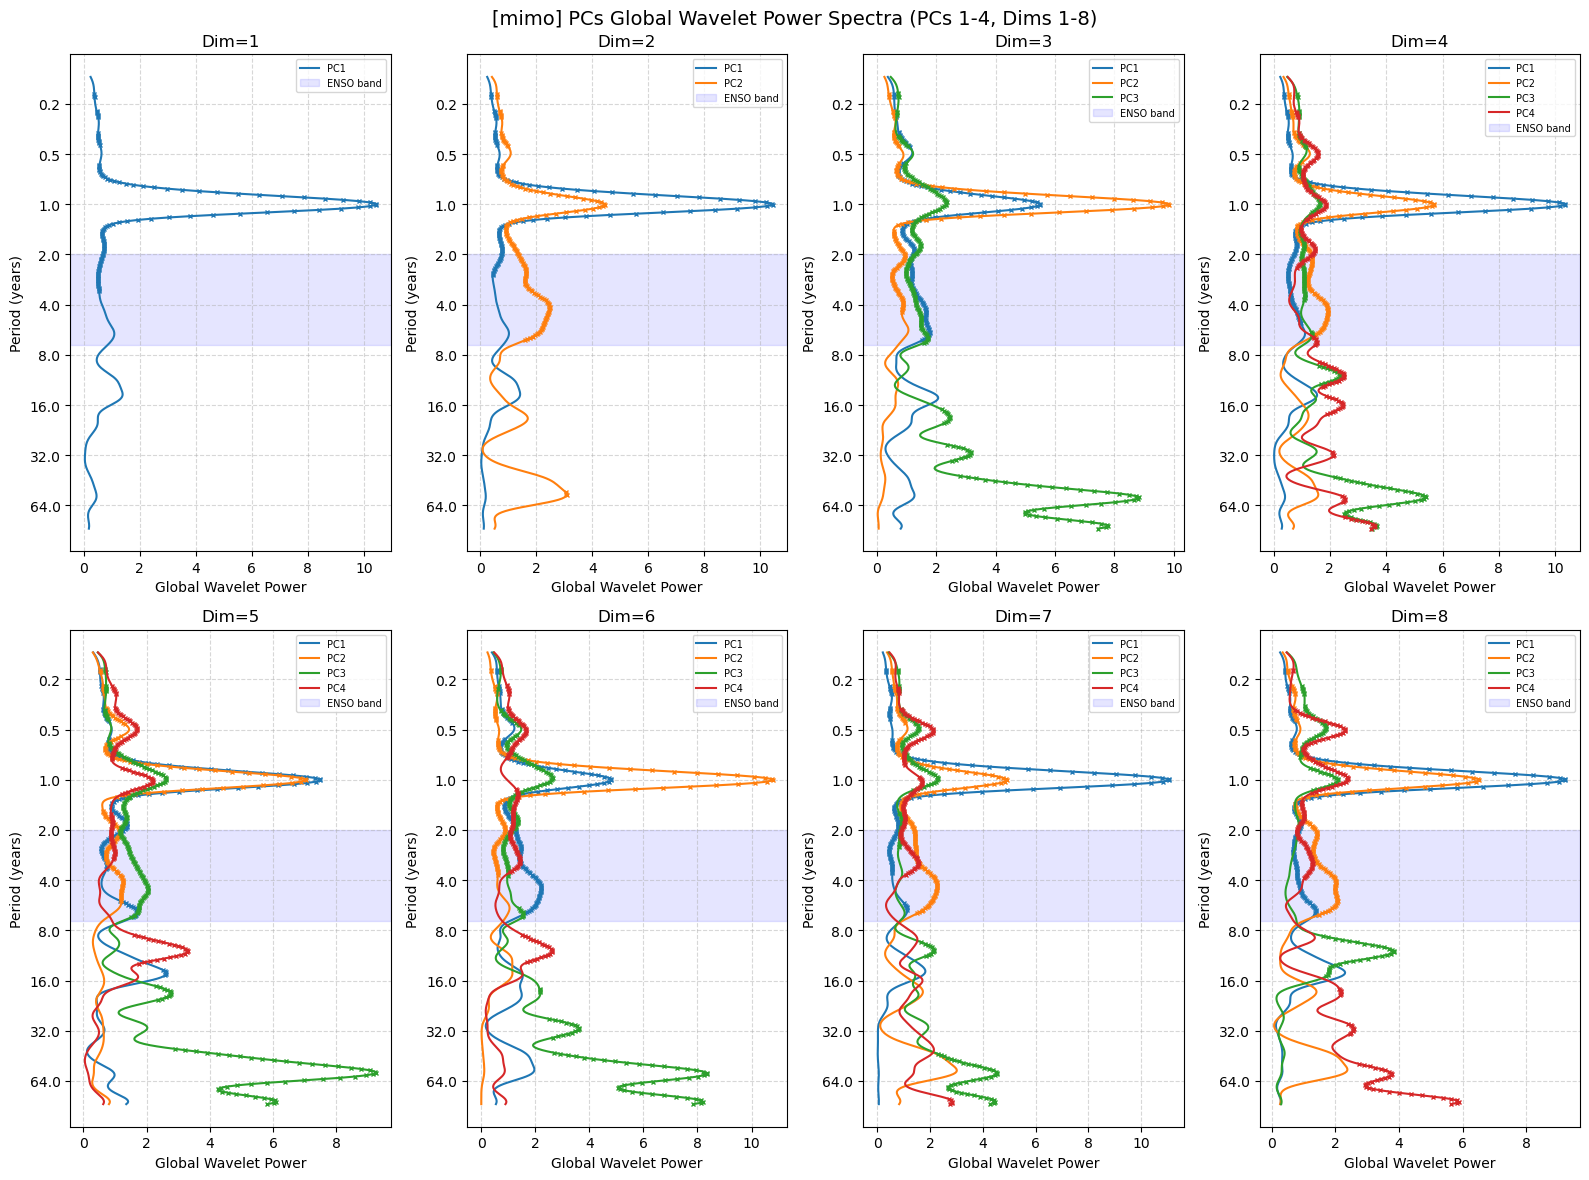

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

dims_to_evaluate = range(1, 9)
siglvl = 0.95
pc_limit = ['PC1', 'PC2', 'PC3', 'PC4']

config = WaveletConfig(dt=1/12, dj=0.025)
wa = WaveletAnalyzer(config)

n_dims = len(list(dims_to_evaluate))
n_cols = 4
n_rows = ceil(n_dims / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 6 * n_rows), sharey=False)
axes = np.array(axes).flatten()

for i, Dim in enumerate(dims_to_evaluate):
    ax = axes[i]
    pc_df = pd.read_csv(f'./results/HD_mimo/D{Dim}/HD_mimo_D{Dim}_PCs.csv', index_col='time', parse_dates=True)
    
    # restrict to PC1-4 and only those that exist in this Dim
    pc_cols = [pc for pc in pc_limit if pc in pc_df.columns]

    for pc in pc_cols:
        ts = pc_df[pc].dropna().values
        ts = (ts - ts.mean()) / ts.std()

        # --- CWT ---
        wlt = wa.cwt(ts)

        # --- Red noise significance ---
        wlt_ci = wa.confidence_interval(wlt, ts, conf=siglvl, noise_type='r')

        avg_power = wlt['avg_power']
        periods = wlt['period']
        sig = wlt_ci['sig']

        # --- Plot power curve ---
        line, = ax.plot(avg_power, periods, label=pc)

        # --- Annotate significant periods ---
        sig_mask = avg_power > sig
        ax.plot(
            avg_power[sig_mask],
            periods[sig_mask],
            'x',
            color=line.get_color(),
            markersize=3,
        )

    ax.axhspan(2, 7, alpha=0.1, color='blue', label='ENSO band')
    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))
    ax.invert_yaxis()
    ax.set_xlabel('Global Wavelet Power')
    ax.set_ylabel('Period (years)')
    ax.set_title(f'Dim={Dim}')
    ax.legend(fontsize=7)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

# --- Hide unused axes ---
for j in range(n_dims, n_rows * n_cols):
    axes[j].set_visible(False)

fig.suptitle('[mimo] PCs Global Wavelet Power Spectra (PCs 1-4, Dims 1-8)', fontsize=14)
plt.tight_layout()
plt.savefig('./results/HD_mimo/mimo_combined_global_wavelet.png', dpi=150, bbox_inches='tight')
plt.show()

# Trying to make the Sophie plot

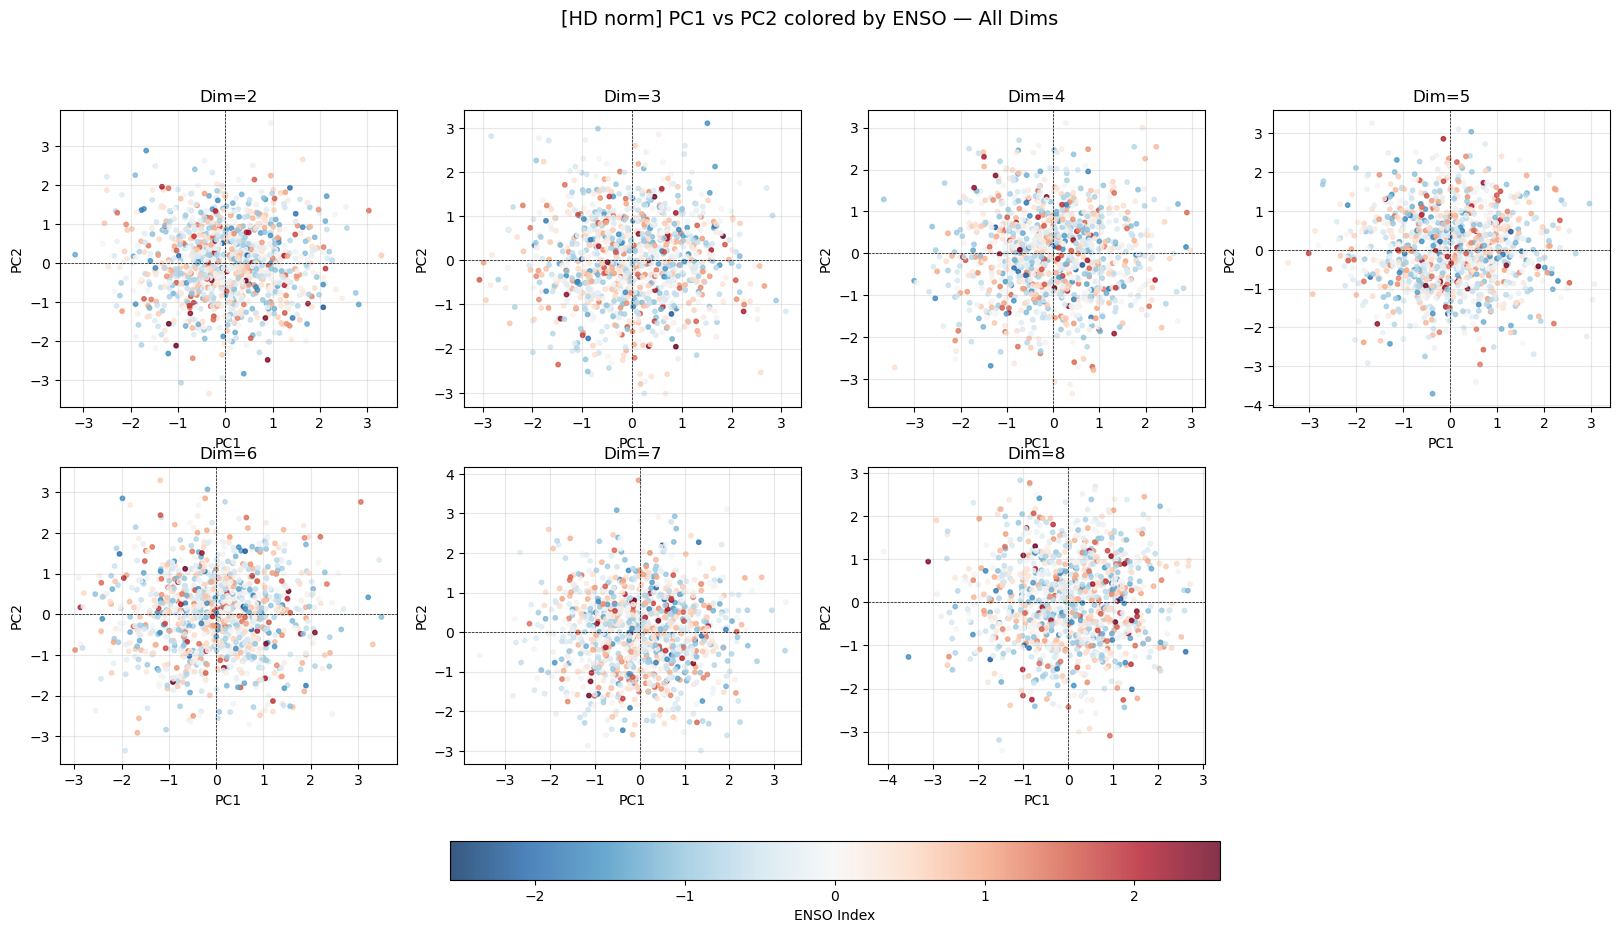

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

dims_to_evaluate = range(2, 9)
n_dims = len(list(dims_to_evaluate))
n_cols = 4
n_rows = ceil(n_dims / n_cols)

# --- Load and align ENSO once ---
enso = nino.rename(columns={'DATE': 'time', 'INDEX': 'value'})
enso['time'] = pd.to_datetime(enso['time'])
enso = enso.set_index('time')
enso.index = enso.index.to_period('M')

# --- Get global ENSO range for consistent colorbar ---
vmin, vmax = enso['value'].min(), enso['value'].max()
vlim = max(abs(vmin), abs(vmax))  # symmetric around zero

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for i, Dim in enumerate(dims_to_evaluate):
    ax = axes[i]

    pc_df = pd.read_csv(f'./results/HD_norm2/D{Dim}/HD_norm2_D{Dim}_PCs.csv', index_col='time', parse_dates=True)
    pc_df.index = pc_df.index.to_period('M')

    combined = pc_df[['PC1', 'PC2']].join(enso[['value']], how='inner')

    sc = ax.scatter(
        combined['PC1'],
        combined['PC2'],
        c=combined['value'],
        cmap='RdBu_r',
        vmin=-vlim, vmax=vlim,
        s=10,
        alpha=0.8
    )

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Dim={Dim}')
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
    ax.grid(True, alpha=0.3)

# --- Hide unused axes ---
for j in range(n_dims, n_rows * n_cols):
    axes[j].set_visible(False)

# --- Shared colorbar ---
cbar = fig.colorbar(sc, ax=axes[:n_dims], orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('ENSO Index')

fig.suptitle('[HD norm] PC1 vs PC2 colored by ENSO — All Dims', fontsize=14)
#plt.tight_layout()
plt.savefig('./results/HD_norm2/combined_PC1_PC2_ENSO.png', dpi=150, bbox_inches='tight')
plt.show()

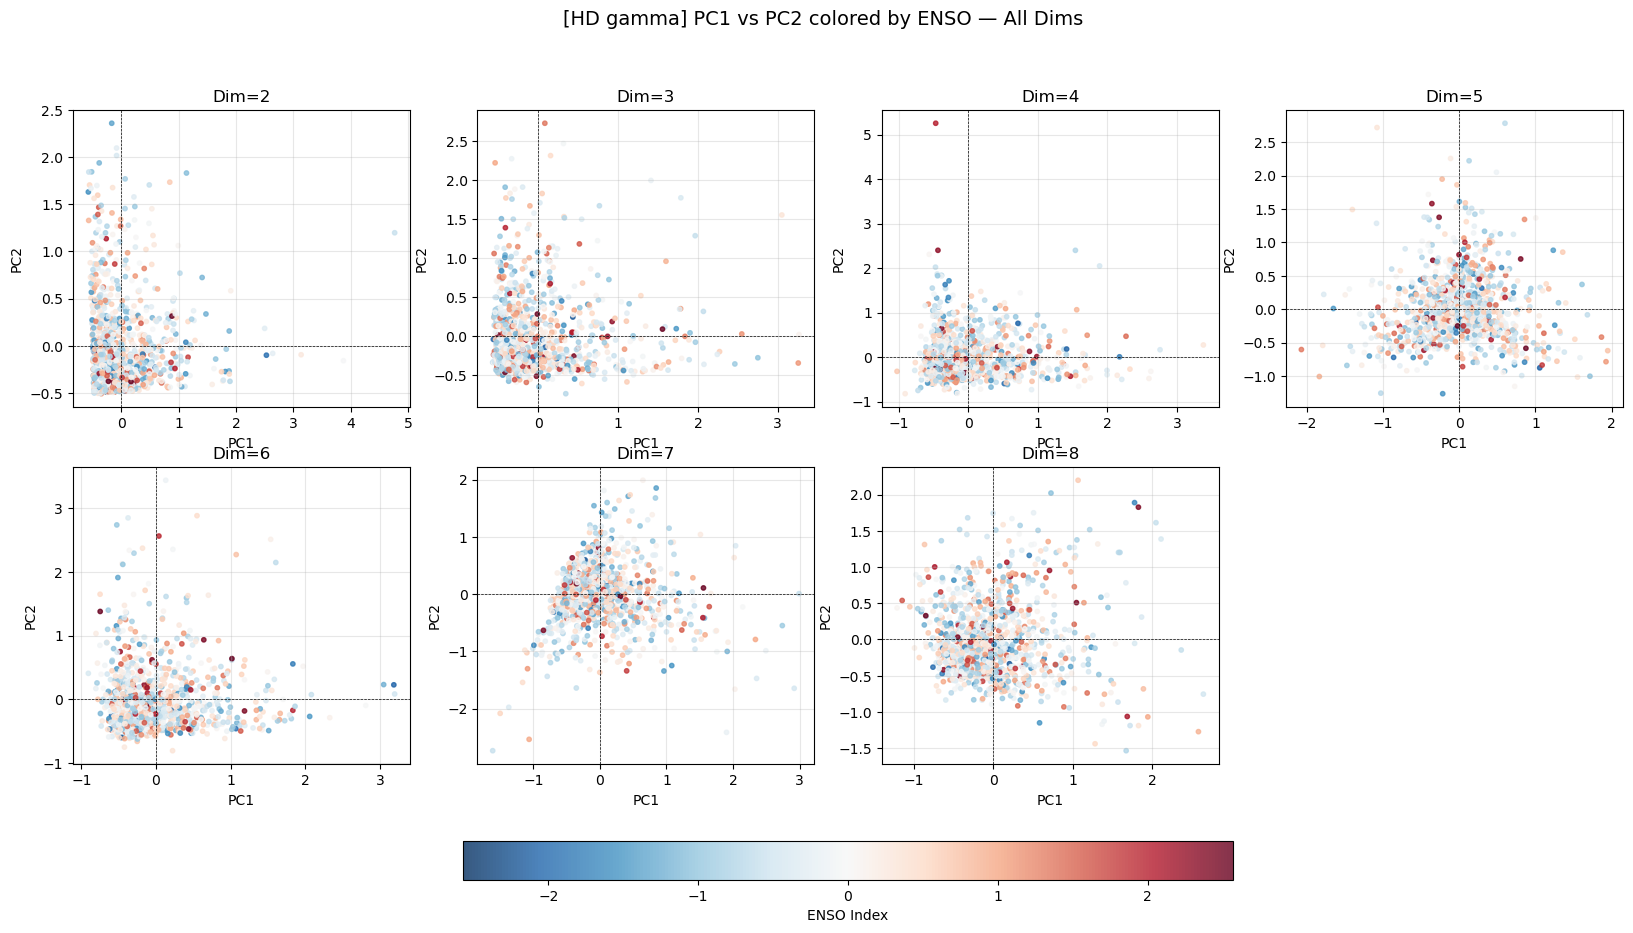

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

dims_to_evaluate = range(2, 9)
n_dims = len(list(dims_to_evaluate))
n_cols = 4
n_rows = ceil(n_dims / n_cols)

# --- Load and align ENSO once ---
enso = nino.rename(columns={'DATE': 'time', 'INDEX': 'value'})
enso['time'] = pd.to_datetime(enso['time'])
enso = enso.set_index('time')
enso.index = enso.index.to_period('M')

# --- Get global ENSO range for consistent colorbar ---
vmin, vmax = enso['value'].min(), enso['value'].max()
vlim = max(abs(vmin), abs(vmax))  # symmetric around zero

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for i, Dim in enumerate(dims_to_evaluate):
    ax = axes[i]

    pc_df = pd.read_csv(f'./results/HD_gamma2/D{Dim}/HD_gamma2_D{Dim}_PCs.csv', index_col='time', parse_dates=True)
    pc_df.index = pc_df.index.to_period('M')

    combined = pc_df[['PC1', 'PC2']].join(enso[['value']], how='inner')

    sc = ax.scatter(
        combined['PC1'],
        combined['PC2'],
        c=combined['value'],
        cmap='RdBu_r',
        vmin=-vlim, vmax=vlim,
        s=10,
        alpha=0.8
    )

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Dim={Dim}')
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
    ax.grid(True, alpha=0.3)

# --- Hide unused axes ---
for j in range(n_dims, n_rows * n_cols):
    axes[j].set_visible(False)

# --- Shared colorbar ---
cbar = fig.colorbar(sc, ax=axes[:n_dims], orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('ENSO Index')

fig.suptitle('[HD gamma] PC1 vs PC2 colored by ENSO — All Dims', fontsize=14)
#plt.tight_layout()
plt.savefig('./results/HD_gamma2/combined_PC1_PC2_ENSO.png', dpi=150, bbox_inches='tight')
plt.show()